# 12 — Product-Level Stockout Analysis
## SunnyBest Retail Forecasting System

### Questions this notebook answers

| # | Question |
|---|----------|
| 1 | Which products stock out the most? |
| 2 | Are these high-demand or high-value products? |
| 3 | Are there patterns across categories? |
| 4 | Do promotions make product-level stockouts worse? |

### Why product-level matters
Store-level analysis tells you *where* the problem is. Product-level analysis tells you *what* is running out.  
A product that stockouts frequently AND has high demand is the highest-priority fix — it is actively costing revenue every time it runs out.

A product that stockouts but has low demand is less urgent — the real question there is whether it should even be stocked at all.

---
## 0. Setup & Data Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from sqlalchemy import create_engine
from urllib.parse import quote_plus

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

plt.rcParams["figure.figsize"]    = (14, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
PALETTE = ["#4C72B0","#C44E52","#55A868","#DD8452","#8172B2","#64B5CD","#CCB974","#777777"]

host     = "aws-1-eu-central-1.pooler.supabase.com"
port     = 5432
database = "postgres"
user     = "postgres.ogkdfmkybqtrsglcizzt"
password = quote_plus("Bonabosssfs01")

engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}",
    pool_pre_ping=True
)

df_calendar   = pd.read_sql("SELECT * FROM core.dim_calendar ORDER BY date ASC", engine)
df_products   = pd.read_sql("SELECT * FROM core.dim_products ORDER BY product_id ASC", engine)
df_stores     = pd.read_sql("SELECT * FROM core.dim_stores ORDER BY store_id ASC", engine)
df_sales      = pd.read_sql("SELECT * FROM core.fact_sales ORDER BY date ASC", engine)
df_inventory  = pd.read_sql("SELECT * FROM core.fact_inventory ORDER BY date ASC", engine)
df_promotions = pd.read_sql("SELECT * FROM core.fact_promotions ORDER BY date ASC", engine)

for d in [df_sales, df_inventory, df_promotions, df_calendar]:
    d["date"] = pd.to_datetime(d["date"])

print(f"Inventory rows : {len(df_inventory):,}")
print(f"Products       : {df_products['product_id'].nunique()}")
print(f"Sales rows     : {len(df_sales):,}")

Inventory rows : 1,633,800
Products       : 120
Sales rows     : 1,633,800


---
## 1. Define Stockouts & Build Product Master

In [2]:
inv = df_inventory.merge(df_products, on="product_id", how="left")
inv = inv.merge(df_calendar[["date","season","month"]], on="date", how="left")

if "stockout_flag" in inv.columns:
    inv["is_stockout"] = inv["stockout_flag"].fillna(0).astype(int)
else:
    inv["is_stockout"] = (inv["stock_level"].fillna(0) == 0).astype(int)

# Demand signal from sales
demand = (df_sales.groupby("product_id")
            .agg(total_units =("units_sold","sum"),
                 avg_daily   =("units_sold","mean"),
                 avg_price   =("price","mean"))
            .reset_index())
demand["avg_daily_revenue"] = demand["avg_daily"] * demand["avg_price"]

# Product-level stockout summary
prod_summary = (inv.groupby("product_id")
                  .agg(total_obs    =("is_stockout","count"),
                       stockout_obs =("is_stockout","sum"))
                  .reset_index())
prod_summary["stockout_rate_pct"] = (
    prod_summary["stockout_obs"] / prod_summary["total_obs"] * 100
).round(2)

prod_summary = (prod_summary
                .merge(df_products[["product_id","product_name","category","regular_price","cost_price"]], on="product_id", how="left")
                .merge(demand, on="product_id", how="left")
                .sort_values("stockout_rate_pct", ascending=False))

print(f"Products tracked: {len(prod_summary):,}")
display(prod_summary[["product_name","category","regular_price",
                       "stockout_obs","stockout_rate_pct","avg_daily"]].head(20))

Products tracked: 120


,product_name,category,regular_price,stockout_obs,stockout_rate_pct,avg_daily
103,9mobile Telecom Model-107,Telecom Services,5563,2114,15.53,13.922071
28,Glo Telecom Model-180,Telecom Services,8054,2109,15.49,21.744253
51,9mobile Telecom Model-260,Telecom Services,690,2074,15.23,20.026735
94,9mobile Telecom Model-544,Telecom Services,3641,1979,14.54,22.037459
70,MTN Telecom Model-711,Telecom Services,7117,1980,14.54,22.595446
112,Oraimo Accessories Model-122,Accessories,11860,1816,13.34,5.954389
101,Generic Accessories Model-332,Accessories,15843,1717,12.61,4.829232
67,Oraimo Accessories Model-680,Accessories,5343,1710,12.56,3.661917
6,Generic Accessories Model-415,Accessories,16502,1705,12.52,3.988836
72,Generic Accessories Model-424,Accessories,13922,1676,12.31,3.143224


---
## 2. Are the Most Stocked-Out Products High-Demand or High-Value?

> The scatter plot places each product in one of four quadrants:  
> - **Top-right**: High demand + high stockout rate → **critical — fix immediately**  
> - **Top-left**: Low demand + high stockout rate → question whether to stock at all  
> - **Bottom-right**: High demand + low stockout rate → well-managed  
> - **Bottom-left**: Low demand + low stockout rate → fine to ignore

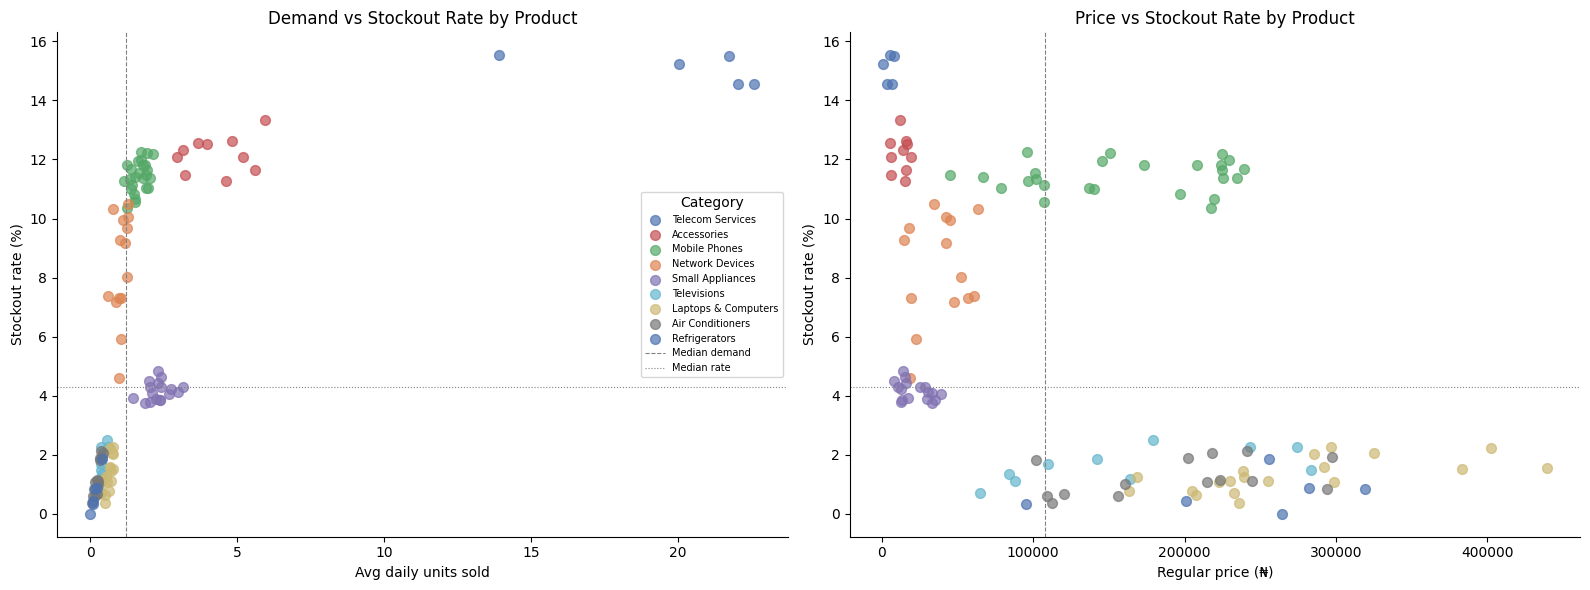


Critical products (high demand + high stockout rate): 50


,product_name,category,avg_daily,regular_price,stockout_rate_pct
103,9mobile Telecom Model-107,Telecom Services,13.922071,5563,15.53
28,Glo Telecom Model-180,Telecom Services,21.744253,8054,15.49
51,9mobile Telecom Model-260,Telecom Services,20.026735,690,15.23
94,9mobile Telecom Model-544,Telecom Services,22.037459,3641,14.54
70,MTN Telecom Model-711,Telecom Services,22.595446,7117,14.54
112,Oraimo Accessories Model-122,Accessories,5.954389,11860,13.34
101,Generic Accessories Model-332,Accessories,4.829232,15843,12.61
67,Oraimo Accessories Model-680,Accessories,3.661917,5343,12.56
6,Generic Accessories Model-415,Accessories,3.988836,16502,12.52
72,Generic Accessories Model-424,Accessories,3.143224,13922,12.31


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: demand vs stockout rate, coloured by category
cats = prod_summary["category"].dropna().unique()
for i, cat in enumerate(cats):
    sub = prod_summary[prod_summary["category"] == cat]
    axes[0].scatter(sub["avg_daily"], sub["stockout_rate_pct"],
                    label=cat, color=PALETTE[i % len(PALETTE)], alpha=0.7, s=50)

axes[0].axvline(prod_summary["avg_daily"].median(), color="grey", ls="--", lw=0.8, label="Median demand")
axes[0].axhline(prod_summary["stockout_rate_pct"].median(), color="grey", ls=":", lw=0.8, label="Median rate")
axes[0].set_xlabel("Avg daily units sold")
axes[0].set_ylabel("Stockout rate (%)")
axes[0].set_title("Demand vs Stockout Rate by Product")
axes[0].legend(fontsize=7, title="Category")

# Scatter: price vs stockout rate
for i, cat in enumerate(cats):
    sub = prod_summary[prod_summary["category"] == cat]
    axes[1].scatter(sub["regular_price"], sub["stockout_rate_pct"],
                    label=cat, color=PALETTE[i % len(PALETTE)], alpha=0.7, s=50)

axes[1].axvline(prod_summary["regular_price"].median(), color="grey", ls="--", lw=0.8)
axes[1].axhline(prod_summary["stockout_rate_pct"].median(), color="grey", ls=":", lw=0.8)
axes[1].set_xlabel("Regular price (₦)")
axes[1].set_ylabel("Stockout rate (%)")
axes[1].set_title("Price vs Stockout Rate by Product")

plt.tight_layout()
plt.show()

# Priority quadrant: high demand AND high stockout rate
demand_thresh  = prod_summary["avg_daily"].median()
rate_thresh    = prod_summary["stockout_rate_pct"].median()
critical = prod_summary[
    (prod_summary["avg_daily"] >= demand_thresh) &
    (prod_summary["stockout_rate_pct"] >= rate_thresh)
].sort_values("stockout_rate_pct", ascending=False)

print(f"\nCritical products (high demand + high stockout rate): {len(critical)}")
display(critical[["product_name","category","avg_daily","regular_price","stockout_rate_pct"]].head(15))

---
## 3. Category-Level Stockout Patterns

> Categories that stockout more may have longer lead times, less predictable demand, or lower safety stock allocations.

In [4]:
cat_summary = (inv.groupby("category")
                 .agg(total_obs   =("is_stockout","count"),
                      stockout_obs=("is_stockout","sum"),
                      products    =("product_id","nunique"))
                 .reset_index())
cat_summary["stockout_rate_pct"] = (
    cat_summary["stockout_obs"] / cat_summary["total_obs"] * 100
).round(2)
cat_summary = cat_summary.sort_values("stockout_rate_pct", ascending=False)

# Add avg demand per category
cat_demand = (df_sales.merge(df_products[["product_id","category"]], on="product_id", how="left")
                .groupby("category")["units_sold"].mean().reset_index()
                .rename(columns={"units_sold": "avg_daily_units"}))
cat_summary = cat_summary.merge(cat_demand, on="category", how="left")

display(cat_summary)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(cat_summary["category"], cat_summary["stockout_rate_pct"],
            color=PALETTE[:len(cat_summary)])
axes[0].set_ylabel("Stockout rate (%)")
axes[0].set_title("Stockout Rate by Category")
axes[0].tick_params(axis="x", rotation=30)
for i, row in cat_summary.reset_index().iterrows():
    axes[0].text(i, row["stockout_rate_pct"] + 0.2, f"{row['stockout_rate_pct']:.1f}%",
                 ha="center", fontsize=8)

# Stockout rate vs avg demand per category
axes[1].scatter(cat_summary["avg_daily_units"], cat_summary["stockout_rate_pct"],
                color=PALETTE[0], s=100, zorder=5)
for _, row in cat_summary.iterrows():
    axes[1].annotate(row["category"],
                     (row["avg_daily_units"], row["stockout_rate_pct"]),
                     textcoords="offset points", xytext=(5,3), fontsize=8)
axes[1].set_xlabel("Avg daily units sold")
axes[1].set_ylabel("Stockout rate (%)")
axes[1].set_title("Category: Demand vs Stockout Rate")

plt.tight_layout()
plt.show()

KeyError: 'category'

---
## 4. Do Promotions Drive Product Stockouts?

> Promotions boost demand. If inventory isn't pre-loaded before a promo, stockouts follow.  
> We compare stockout rates on promo days vs non-promo days for each product.

In [ ]:
if "product_id" in inv.columns and "store_id" in inv.columns:
    promo_flag = df_promotions[["date","store_id","product_id","promo_flag","discount_pct"]].copy()
    promo_flag["promo_flag"] = promo_flag["promo_flag"].fillna(0).astype(int)

    inv_promo = inv.merge(promo_flag, on=["date","store_id","product_id"], how="left")
    inv_promo["promo_flag"] = inv_promo["promo_flag"].fillna(0).astype(int)

    # Stockout rate on promo vs non-promo days
    promo_rates = (inv_promo.groupby("promo_flag")
                    .agg(stockout_rate=("is_stockout","mean"),
                         n=("is_stockout","count"))
                    .reset_index())
    promo_rates["stockout_rate"] *= 100
    promo_rates["label"] = promo_rates["promo_flag"].map({0:"No Promo",1:"Promo Day"})

    print("Stockout rate: Promo vs Non-Promo days")
    display(promo_rates[["label","stockout_rate","n"]])

    # By category
    cat_promo = (inv_promo.groupby(["category","promo_flag"])
                   .agg(stockout_rate=("is_stockout","mean"))
                   .reset_index())
    cat_promo["stockout_rate"] *= 100
    cat_promo["label"] = cat_promo["promo_flag"].map({0:"No Promo",1:"Promo"})

    pivot_promo = cat_promo.pivot(index="category", columns="label", values="stockout_rate").fillna(0)
    pivot_promo["uplift_pp"] = (pivot_promo.get("Promo",0) - pivot_promo.get("No Promo",0)).round(2)
    pivot_promo = pivot_promo.sort_values("uplift_pp", ascending=False)

    print("\nPromo stockout uplift by category (percentage points):")
    display(pivot_promo)

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(pivot_promo))
    w = 0.35
    ax.bar(x - w/2, pivot_promo.get("No Promo", [0]*len(pivot_promo)), w,
           label="No Promo", color=PALETTE[0])
    ax.bar(x + w/2, pivot_promo.get("Promo", [0]*len(pivot_promo)), w,
           label="Promo", color=PALETTE[1])
    ax.set_xticks(x)
    ax.set_xticklabels(pivot_promo.index, rotation=30, ha="right")
    ax.set_ylabel("Stockout rate (%)")
    ax.set_title("Stockout Rate: Promo vs Non-Promo Days by Category")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("product_id / store_id not in inventory — skipping promo linkage.")

---
## 5. Top 20 Highest-Risk Products (Revenue × Stockout Rate)

> Combining daily revenue lost with stockout rate gives a single **commercial risk score** per product.  
> These are the products worth prioritising for safety stock increases.

In [ ]:
prod_summary["risk_score"] = (
    prod_summary["stockout_rate_pct"] * prod_summary["avg_daily_revenue"].fillna(0)
).round(2)

top_risk = prod_summary.sort_values("risk_score", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [PALETTE[list(cats).index(c) % len(PALETTE)] if c in cats else PALETTE[0]
          for c in top_risk["category"]]
ax.barh(top_risk["product_name"][::-1], top_risk["risk_score"][::-1], color=colors[::-1])
ax.set_xlabel("Risk score (stockout rate % × avg daily revenue)")
ax.set_title("Top 20 Highest-Risk Products by Commercial Impact")
plt.tight_layout()
plt.show()

display(top_risk[["product_name","category","regular_price",
                  "avg_daily","stockout_rate_pct","risk_score"]].reset_index(drop=True))

---
## 6. Insights

**What this analysis tells you:**
- Products in the **high-demand + high-stockout** quadrant are the real priority — every stockout there is a guaranteed lost sale on a product customers are actively seeking
- Products with high stockout rates but low demand are candidates for **SKU rationalisation** — if customers aren't buying them much anyway, carrying the stockout risk may not be worth it
- If promotions consistently increase stockout rates, the buying team is **not pre-loading inventory** before promos are activated — this is a process gap, not a forecasting gap
- The risk score combines both dimensions into one number — useful for prioritising which products get safety stock increases first

**Sharp questions to ask:**
1. For the top-risk products — what is the current safety stock policy? Is it based on historical demand or gut feel?
2. If a category shows high promo stockout uplift — are promotions being planned with procurement involved, or is marketing running promos without telling the supply chain team?
3. Is there a difference in stockout rates between branded and own-brand products within the same category?